In [28]:
import sys
# !{sys.executable} -m pip install matplotlib
# !{sys.executable} -m pip install mrcfile
# !{sys.executable} -m pip install numpy
# !{sys.executable} -m pip install pandas
# !{sys.executable} -m pip install Pillow
# !{sys.executable} -m pip install POT
# !{sys.executable} -m pip install scipy
# !{sys.executable} -m pip install seaborn
# !{sys.executable} -m pip install numba
# !{sys.executable} -m pip install Bio
# !{sys.executable} -m pip install tornado==4.5.3
!pip freeze

anyio==4.10.0
asttokens==3.0.1
bio==1.8.0
biopython==1.85
biothings_client==0.4.1
certifi==2025.8.3
charset-normalizer==3.4.3
colorama==0.4.6
comm==0.2.3
contourpy==1.3.2
cuda-bindings==12.9.4
cuda-pathfinder==1.4.0
cycler==0.12.1
debugpy==1.8.20
decorator==5.2.1
exceptiongroup==1.3.1
executing==2.2.1
fastjsonschema==2.21.2
filelock==3.25.0
fonttools==4.59.2
fsspec==2026.2.0
gprofiler-official==1.0.0
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.10
ipykernel==7.2.0
ipython==8.39.0
jedi==0.20.0
Jinja2==3.1.6
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyterlab_widgets==3.0.16
kiwisolver==1.4.9
lark==1.3.1
llvmlite==0.44.0
MarkupSafe==3.0.3
matplotlib==3.10.6
matplotlib-inline==0.2.2
mistune==3.2.1
mpmath==1.3.0
mrcfile==1.5.4
mygene==3.2.2
nest-asyncio==1.6.0
networkx==3.4.2
numba==0.61.2
numpy==2.2.6
overrides==7.7.0
packaging==26.2
pandas==2.3.2
pandocfilters==1.5.1
parso==0.8.7
pillow==11.3.0
platformdirs==4.9.6
pooch==1.8.2
POT==0.9.5
prometheus_client==0.25.0
prompt_toolkit==3.

In [29]:
# # %matplotlib notebook
# import matplotlib.pyplot as plt
# import math
# import numpy as np
# import ot
# from matplotlib import collections  as mc
# from mpl_toolkits.mplot3d import Axes3D
# import random
# import time
# import seaborn as sns
# import json

# import mrcfile
# import pandas as pd
# import trn, coords
# import importlib
# importlib.reload(trn)

# import torch
# from unbalancedgw.vanilla_ugw_solver import exp_ugw_sinkhorn
# from unbalancedgw.vanilla_ugw_solver import log_ugw_sinkhorn
# from unbalancedgw._vanilla_utils import ugw_cost
# from unbalancedgw.utils import generate_measure
# from unbalancedgw._vanilla_utils import l2_distortion

# from scipy.spatial.transform import Rotation

# from Bio import PDB
# from Bio.PDB.vectors import Vector, rotmat

# plt.rcParams["figure.figsize"] = (10,10)

In [2]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import ot

import json
import os

from jgw import jgw_wrapper
from cryo_utils import sample_pdb, sample, generate_pdb_no_mrc, mrc_volume
from alignment import build_coup, find_optimal_alignment

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: attempted relative import with no known parent package

In [31]:
# file_path_extensions = ['A', 'B', 'C', 'E', 'F', 'H', 'I', 'J', 'K', 'L']
# file_path_origin = 'Data/jgw/bio/1i3q/1i3q_%s.pdb'
# volumes = np.array([1349, 788, 557, 309, 273, 309, 273, 456])
# n_points = 5000
# num_skip = 10

file_path_extensions = ['A', 'B', 'CHJKL']
file_path_origin = '../../../jgw/bio/1i3q/1i3q_%s.pdb'
volumes = np.array([1349, 788, 557, 309, 273, 309, 273, 456])
n_points = 5000
num_skip = 10

../../../jgw/bio/1i3q/1i3q_A.pdb
(1111, 3)


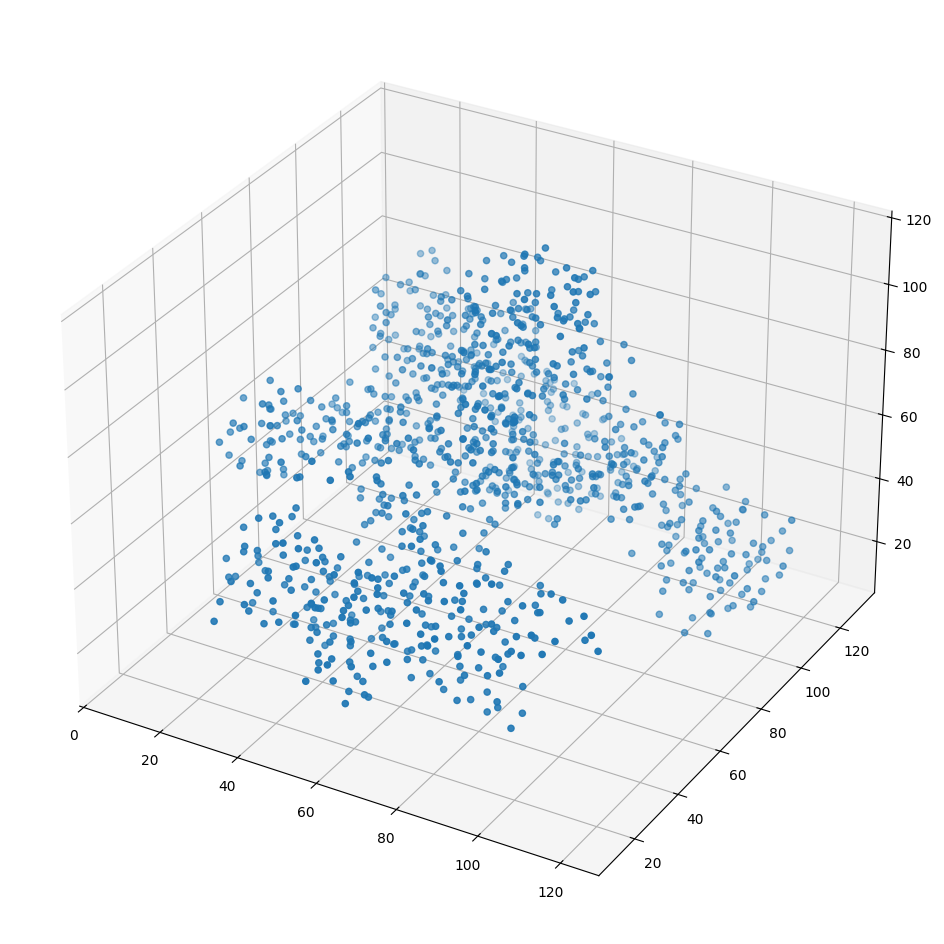

../../../jgw/bio/1i3q/1i3q_B.pdb
(862, 3)


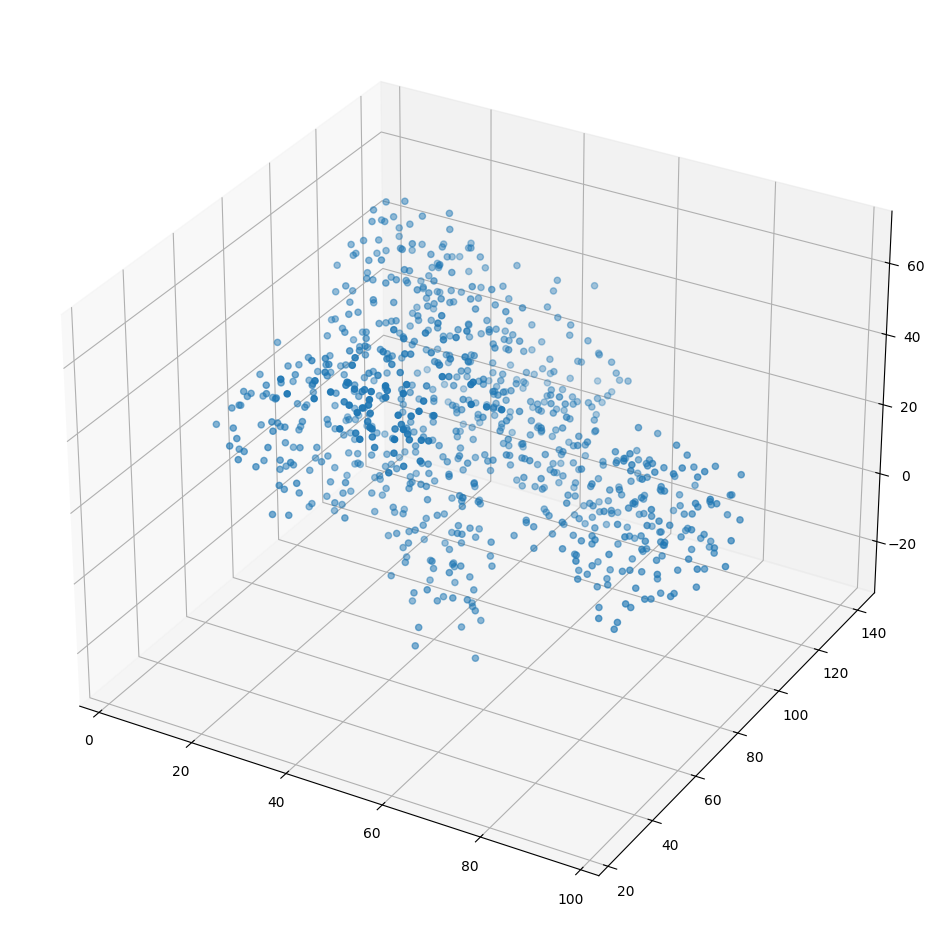

../../../jgw/bio/1i3q/1i3q_CHJKL.pdb
(498, 3)


c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 6409.
  warnings.warn(
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain J is discontinuous at line 6412.
  warnings.warn(
c:\Users\artaj\Data\jgw_github\Joint-Gromov-Wasserstein\.venv\lib\site-packages\Bio\PDB\StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain L is discontinuous at line 6413.
  warnings.warn(


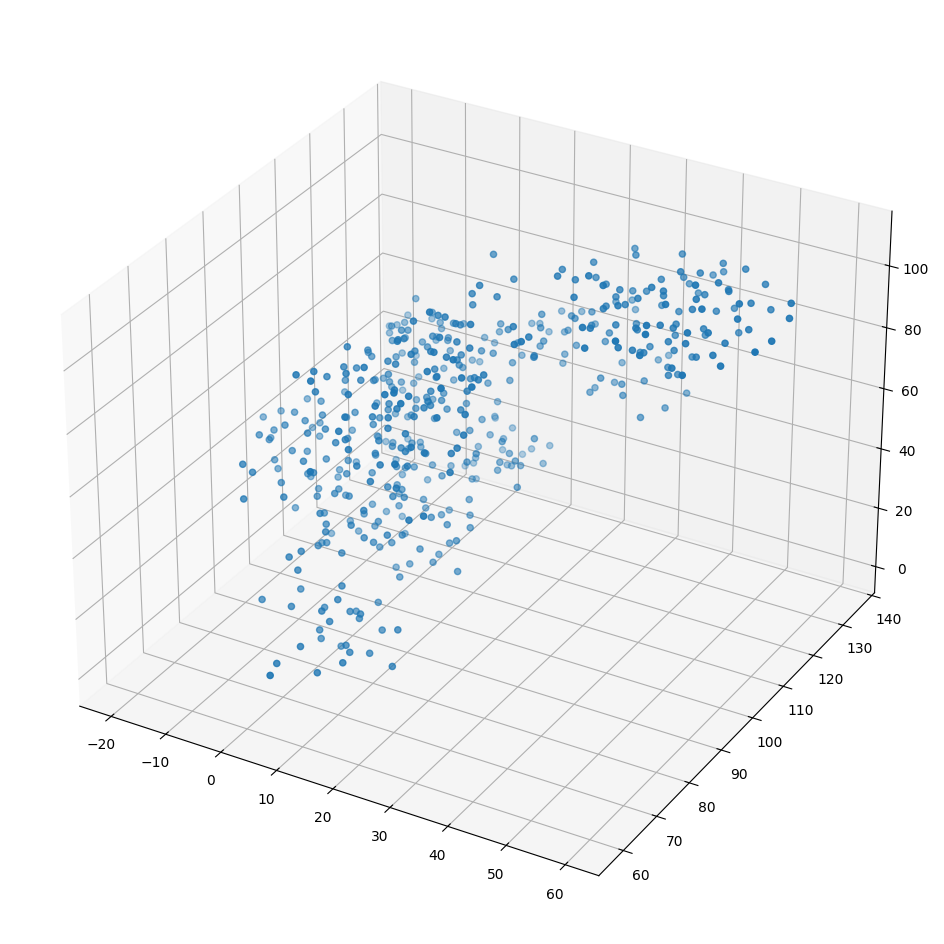

In [32]:
points_x = []
index = []
for i in range(len(file_path_extensions)):
    file_path = file_path_origin%(file_path_extensions[i],)
#     num = int(n_points / volumes.sum() * volumes[i])
#     x, y, z = sample(file_path, 0.1, n_points, random_seed=1)
#     print(file_path, num)
#     points_x.append([])
#     for j in range(num):
#         index.append(i)
#         points_x[-1].append([x[j],y[j],z[j]])
#     points_x[-1] = np.array(points_x[-1])
    points_x.append(sample_pdb(file_path, num_skip))
    print(points_x[-1].shape)
    for j in range(points_x[-1].shape[0]):
        index.append(i)
    
    fig = plt.figure(figsize=(12, 12))
    ax = fig.add_subplot(projection='3d')
    ax.scatter(points_x[-1][:,2], points_x[-1][:,0], points_x[-1][:,1])
    plt.show()

(2471, 3)


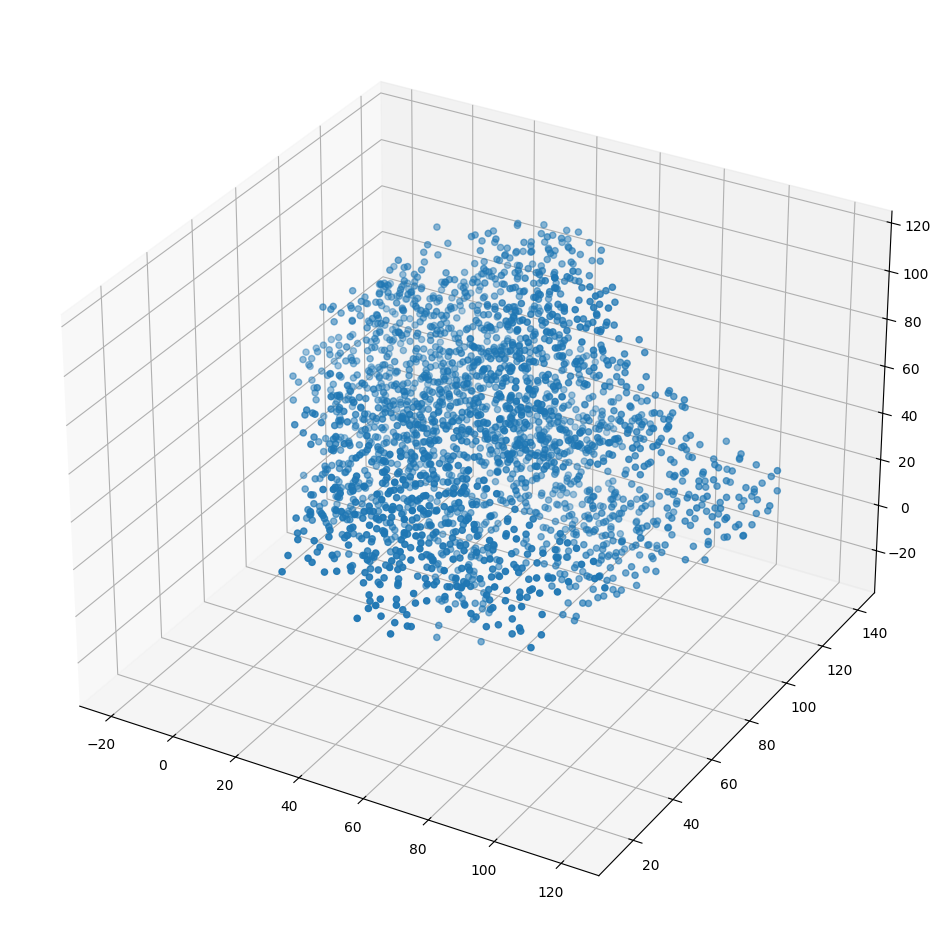

In [33]:
points_y = []
for i in range(len(points_x)):
    for j in range(points_x[i].shape[0]):
        points_y.append([points_x[i][j][0], points_x[i][j][1], points_x[i][j][2]])
points_y = np.array(points_y)

print(points_y.shape)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(points_y[:,2], points_y[:,0], points_y[:,1])
plt.show()

In [ ]:
mu, dif, costs = jgw_wrapper(points_x, points_y, epsilon=1e5, eta=1, verbose=False, max_iter=50, diff_thrsh=1e-3)

In [ ]:
# d_y, i_y = generate_d([points_y])
# mu_y = [1/d_y.shape[0]] * d_y.shape[0]
# mu_y = np.array(mu_y)

In [ ]:
# d_x, i_x = generate_d(points_x)
# mu_x = [1/d_x.shape[0]] * d_x.shape[0]
# mu_x = np.array(mu_x)

In [ ]:
# plt.imshow(d_x)
# plt.show()
# plt.imshow(d_y)
# plt.show()

In [ ]:
# eta = 1
# import time
# alpha = 1e5
# cur_mu = np.outer(mu_x, mu_y)
# print(cur_mu.sum())
# dif = []
# costs = []
# mus = []
# for i in range(50):
#     t = time.time()
#     c = gamma(cur_mu, d_x, i_x, d_y)
#     c_o = c
#     c -= c.min()
#     c = (c**eta) * (cur_mu**(1-eta))
    
# #     plt.imshow(c)
# #     plt.show()
# #     print(c)
    
    
#     k = 1/c.sum() *c.shape[0] * c.shape[1]
#     c = c*k
#     alpha1=alpha*k
#     mu = ot.sinkhorn(mu_x, mu_y, c, alpha1)
#     print('#####')
#     print(i)
#     print(k)
#     print(abs(mu - cur_mu).sum())
#     print(mu.sum())
#     dif.append(abs(mu - cur_mu).sum())
#     costs.append(cost(c_o, cur_mu))
#     plt.imshow(cur_mu)
#     plt.show()
# #     plt.imshow(c)
#     plt.show()
#     cur_mu = mu
# #     if dif[-1] < 1e-4:
# #         cur_mu = np.random.rand(mu.shape[0], mu.shape[1])
# #         cur_mu /= cur_mu.sum()
#     mus.append(cur_mu)
#     print(time.time() - t)

In [ ]:
fig = plt.figure(figsize=(4, 4))
plt.plot(dif)
plt.yscale('log')
plt.ylabel('error')
plt.xlabel('iteration')
plt.show()

In [ ]:
plt.imshow(mu)
plt.show()

In [2]:
base_path = '../../../embuild-server/embuild/'
name = '5A5T'

# f = open(base_path + name + "chains/hyper.json", 'r')
# hyper = json.load(f)
# f.close()

file_path_y = base_path + "maps/" + name + "_map.mrc"

# chain_ids = []
# file_paths_x = []
# for c in hyper["chain_files"]:
#     chain_ids.append(c.split('.')[0].split('_')[-1])
#     file_paths_x.append(base_path + name + "chains/maps/" + name + "_chain_" + chain_ids[-1] + "_map.mrc")
chain_ids = ['A', 'C', 'E', 'F', 'H', 'K', 'L', 'M']
file_paths_x = [base_path + name + "chains/maps/" + name + "_chain_" + chain_id + "_map.mrc" for chain_id in chain_ids]
volumes = np.array([4935, 4529, 3466, 2111, 2624, 1738, 3110, 2919])

# volumes = np.array(hyper["num_atoms"])
# for i in range(len(file_paths_x)):
#     print(mrc_volume())
#     volumes = np.array(hyper["num_atoms"])



../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_A_map.mrc 194
cluster 0 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_C_map.mrc 178
cluster 1 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_E_map.mrc 136
cluster 2 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_F_map.mrc 83
cluster 3 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_H_map.mrc 103
cluster 4 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_K_map.mrc 68
cluster 5 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_L_map.mrc 122
cluster 6 is sampled.
../../../embuild-server/embuild/5A5Tchains/maps/5A5T_chain_M_map.mrc 114
cluster 7 is sampled.
../../../embuild-server/embuild/maps/5A5T_map.mrc 1000
(1000, 3)
points_y is sampled.


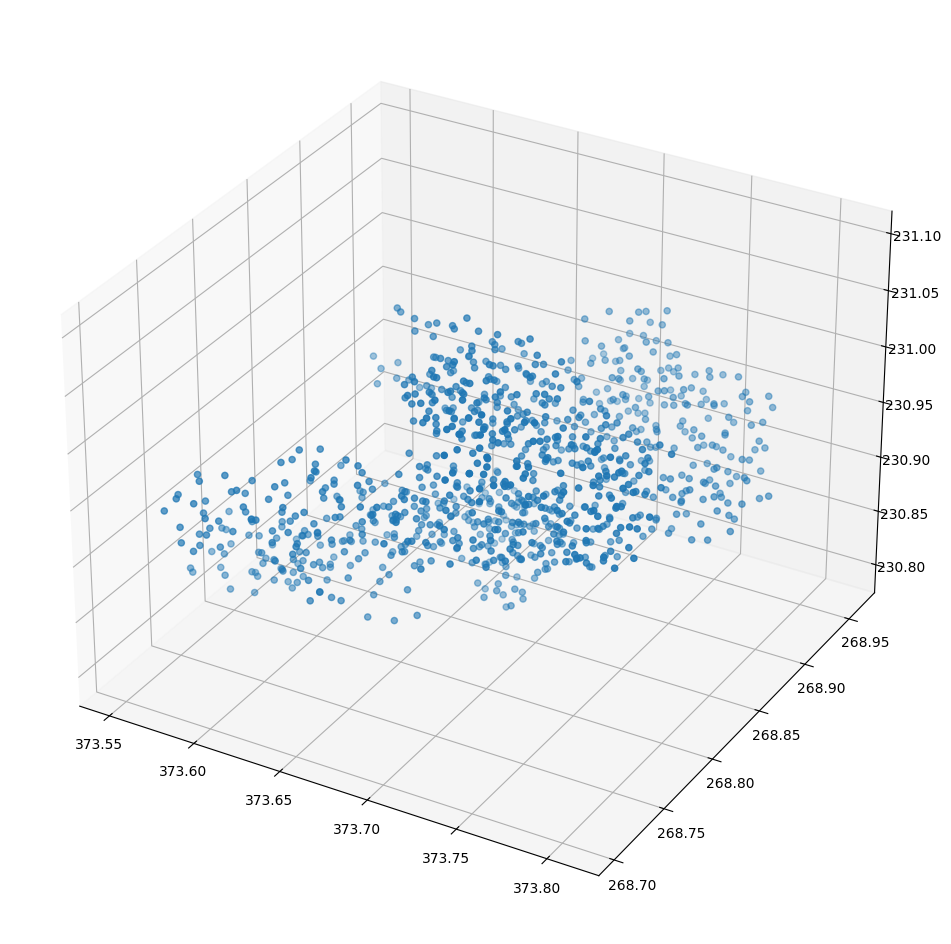

In [21]:
n_points = 1000


optimal_cost = 1e10
optimal_idx = 0
points_x = []
index = []
for i in range(len(file_paths_x)):
    file_path = file_paths_x[i]
    num = int(n_points / volumes.sum() * volumes[i])
    x, y, z = sample(file_path, 0.03, num, random_seed=1, method='cvt')
    print(file_path, num)
    points_x.append([])
    for j in range(num):
        index.append(i)
        points_x[-1].append([x[j],y[j],z[j]])
    points_x[-1] = np.array(points_x[-1])

    # print(points_x[-1].shape)
    print("cluster %d is sampled."%(i,))


points_y = []
x, y, z = sample(file_path_y, 0.03, n_points, random_seed=1, method='cvt')
print(file_path_y, n_points)
for j in range(n_points):
    points_y.append([x[j],y[j],z[j]])

points_y = np.array(points_y)

print(points_y.shape)
print("points_y is sampled.")


fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(points_y[:,2], points_y[:,0], points_y[:,1])
plt.show()



In [42]:
mu, dif, costs = jgw_wrapper(points_x, points_y, epsilon=1e7, max_iter=500, ot_solver='emd', diff_thrsh=1e-3)

print("JGW finished")

JGW finished


In [41]:
x = []
y = []
z = []
for i in range(points_y.shape[0]):
    x.append(points_y[i, 0])
    y.append(points_y[i, 1])
    z.append(points_y[i, 2])

ss = 0
for k in range(len(file_paths_x)):
    x1 = []
    y1 = []
    z1 = []
    for i in range(points_x[k].shape[0]):
        x1.append(points_x[k][i, 0])
        y1.append(points_x[k][i, 1])
        z1.append(points_x[k][i, 2])

    all_coup = build_coup(x, y, z, x1, y1, z1, mu[ss: , ])

    Abar, Bbar, r = find_optimal_alignment(x, y, z, x1, y1, z1, all_coup)
    print("Alignment of complex %s chain %d"%(name, k))
    print("Abar: ", Abar)
    print("Bbar: ", Bbar)
    print("r: ", r.as_rotvec(degrees=True))
    print("Translational diff: ", np.linalg.norm(Abar - Bbar))
    print("Rotational diff: ", np.linalg.norm(r.as_rotvec(degrees=True)))
    alignment = {'Abar':Abar, 'Bbar':Bbar, 'r':r}

    # os.makedirs("data/output/" + name + "chains/", exist_ok=True)
    os.makedirs("../output/", exist_ok=True)
    out_path = ("../output/" + name + "_JGW_output_%s.pdb")%(chain_ids[k])
    generate_pdb_no_mrc((base_path + name + "chains/" + name + "_chain_%s.pdb")%(chain_ids[k],), out_path, alignment)

    ss += len(x1)

Alignment of complex 5A5T chain 0
Abar:  [268.8226296  230.93280835 373.6396887 ]
Bbar:  [242.41033112 246.7795084  359.12361346]
r:  [-92.23789768  44.38612972 116.12235974]
Translational diff:  34.05060725259116
Rotational diff:  154.7978059019569
../../../embuild-server/embuild/5A5Tchains/5A5T_chain_A.pdb
Alignment of complex 5A5T chain 1
Abar:  [268.81572561 230.92652447 373.64231208]
Bbar:  [261.82157798 214.22522946 340.71040051]
r:  [-49.0768837  112.84861037  78.87533656]
Translational diff:  37.58140704492017
Rotational diff:  146.16657652417274
../../../embuild-server/embuild/5A5Tchains/5A5T_chain_C.pdb
Alignment of complex 5A5T chain 2
Abar:  [268.81094682 230.92948985 373.67177631]
Bbar:  [295.72516841 199.25222962 381.23451766]
r:  [-120.45145767   30.07767291   49.09586849]
Translational diff:  42.249487529246
Rotational diff:  133.50514734050472
../../../embuild-server/embuild/5A5Tchains/5A5T_chain_E.pdb
Alignment of complex 5A5T chain 3
Abar:  [268.76162687 230.84146768

In [36]:
points_y.shape

(1000, 3)

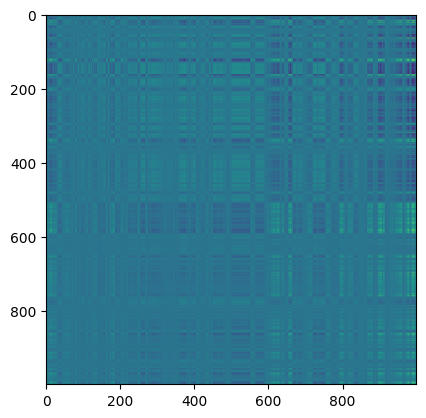

In [37]:
plt.imshow(mu*10000)

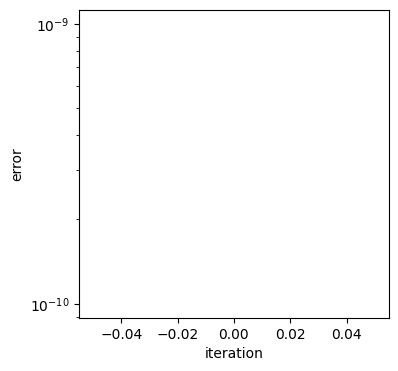

In [38]:
fig = plt.figure(figsize=(4, 4))
plt.plot(dif)
plt.yscale('log')
plt.ylabel('error')
plt.xlabel('iteration')
plt.show()

In [15]:
# all_coup